In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [7]:
# Load Data
data = pd.read_csv('/content/gdrive/MyDrive/Data science Project/Dataset.csv')
data

,Year,Month,DOMESTIC,INTERNATIONAL,TOTAL
0,2005,9,"9,495",NaN,"9,495"
1,2005,10,"13,125",NaN,"13,125"
2,2005,11,"27,905",NaN,"27,905"
3,2005,12,"40,463",NaN,"40,463"
4,2005,TOTAL,"90,988",0,"90,988"
...,...,...,...,...,...
237,2023,12,"1,300,656","119,454","1,420,110"
238,2023,TOTAL,"16,359,042","1,214,578","17,573,620"
239,2024,1,"1,123,966","119,132","1,243,098"
240,2024,2,"1,147,545","121,245","1,268,790"


In [8]:
# Remove rows with 'TOTAL' in the Month column
data = data[data['Month'] != 'TOTAL']
data

,Year,Month,DOMESTIC,INTERNATIONAL,TOTAL
0,2005,9,"9,495",NaN,"9,495"
1,2005,10,"13,125",NaN,"13,125"
2,2005,11,"27,905",NaN,"27,905"
3,2005,12,"40,463",NaN,"40,463"
5,2006,1,"49,275",NaN,"49,275"
...,...,...,...,...,...
235,2023,10,"1,417,171","113,841","1,531,012"
236,2023,11,"1,353,528","112,748","1,466,276"
237,2023,12,"1,300,656","119,454","1,420,110"
239,2024,1,"1,123,966","119,132","1,243,098"


In [9]:
# List of columns to convert
columns_to_convert = ['DOMESTIC', 'INTERNATIONAL', 'TOTAL']

# Loop through each column and apply conversion
for col in columns_to_convert:
     data.loc[:, col] = pd.to_numeric(data[col].str.replace(',', ''), errors='coerce').fillna(0)
data

,Year,Month,DOMESTIC,INTERNATIONAL,TOTAL
0,2005,9,9495,0.0,9495
1,2005,10,13125,0.0,13125
2,2005,11,27905,0.0,27905
3,2005,12,40463,0.0,40463
5,2006,1,49275,0.0,49275
...,...,...,...,...,...
235,2023,10,1417171,113841.0,1531012
236,2023,11,1353528,112748.0,1466276
237,2023,12,1300656,119454.0,1420110
239,2024,1,1123966,119132.0,1243098


In [10]:
data.loc[:, 'INTERNATIONAL'] = data['INTERNATIONAL'].fillna(0)
data

,Year,Month,DOMESTIC,INTERNATIONAL,TOTAL
0,2005,9,9495,0.0,9495
1,2005,10,13125,0.0,13125
2,2005,11,27905,0.0,27905
3,2005,12,40463,0.0,40463
5,2006,1,49275,0.0,49275
...,...,...,...,...,...
235,2023,10,1417171,113841.0,1531012
236,2023,11,1353528,112748.0,1466276
237,2023,12,1300656,119454.0,1420110
239,2024,1,1123966,119132.0,1243098


In [11]:
data = data.assign(Date=pd.to_datetime(data[['Year', 'Month']].assign(DAY=1)))
data.set_index('Date', inplace=True)
data.index.freq = 'MS'
data.drop(['Year', 'Month'], axis=1, inplace=True)
data

,DOMESTIC,INTERNATIONAL,TOTAL
Date,,,
2005-09-01,9495,0.0,9495
2005-10-01,13125,0.0,13125
2005-11-01,27905,0.0,27905
2005-12-01,40463,0.0,40463
2006-01-01,49275,0.0,49275
...,...,...,...
2023-10-01,1417171,113841.0,1531012
2023-11-01,1353528,112748.0,1466276
2023-12-01,1300656,119454.0,1420110


In [12]:
# Optional: Feature engineering (lagged features)
data = data.assign(DOMESTIC_LAG1=data['DOMESTIC'].shift(1).fillna(0),
                   INTERNATIONAL_LAG1=data['INTERNATIONAL'].shift(1).fillna(0),
                   TOTAL_LAG1=data['TOTAL'].shift(1).fillna(0))
data

,DOMESTIC,INTERNATIONAL,TOTAL,DOMESTIC_LAG1,INTERNATIONAL_LAG1,TOTAL_LAG1
Date,,,,,,
2005-09-01,9495,0.0,9495,0,0.0,0
2005-10-01,13125,0.0,13125,9495,0.0,9495
2005-11-01,27905,0.0,27905,13125,0.0,13125
2005-12-01,40463,0.0,40463,27905,0.0,27905
2006-01-01,49275,0.0,49275,40463,0.0,40463
...,...,...,...,...,...,...
2023-10-01,1417171,113841.0,1531012,1338094,97285.0,1435379
2023-11-01,1353528,112748.0,1466276,1417171,113841.0,1531012
2023-12-01,1300656,119454.0,1420110,1353528,112748.0,1466276


In [13]:
data['TOTAL'] = pd.to_numeric(data['TOTAL'], errors='coerce')
data.dropna(inplace=True)
data

,DOMESTIC,INTERNATIONAL,TOTAL,DOMESTIC_LAG1,INTERNATIONAL_LAG1,TOTAL_LAG1
Date,,,,,,
2005-09-01,9495,0.0,9495,0,0.0,0
2005-10-01,13125,0.0,13125,9495,0.0,9495
2005-11-01,27905,0.0,27905,13125,0.0,13125
2005-12-01,40463,0.0,40463,27905,0.0,27905
2006-01-01,49275,0.0,49275,40463,0.0,40463
...,...,...,...,...,...,...
2023-10-01,1417171,113841.0,1531012,1338094,97285.0,1435379
2023-11-01,1353528,112748.0,1466276,1417171,113841.0,1531012
2023-12-01,1300656,119454.0,1420110,1353528,112748.0,1466276


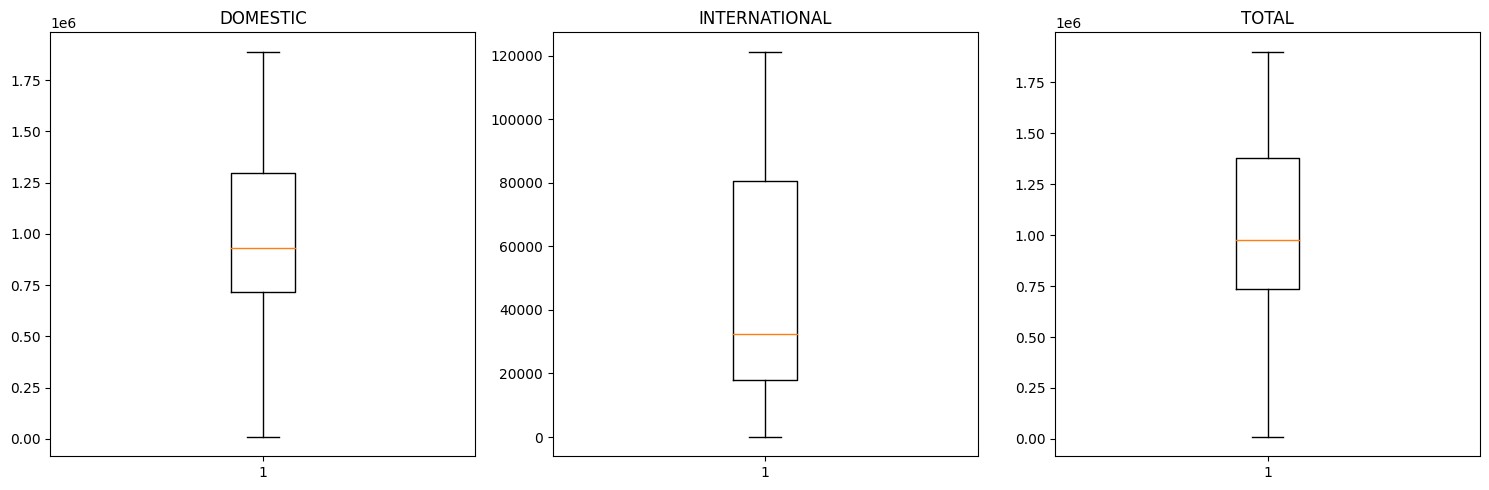

In [14]:
 #Create box plots for each column
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.boxplot(data['DOMESTIC'])
plt.title('DOMESTIC')

plt.subplot(1, 3, 2)
plt.boxplot(data['INTERNATIONAL'])
plt.title('INTERNATIONAL')

plt.subplot(1, 3, 3)
plt.boxplot(data['TOTAL'])
plt.title('TOTAL')

plt.tight_layout()
plt.show()

In [15]:
# Define a function to identify outliers using the IQR method
def find_outliers_iqr(data_series):
    Q1 = data_series.quantile(0.25)
    Q3 = data_series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data_series[(data_series < lower_bound) | (data_series > upper_bound)]
    return outliers

# Find outliers in each column
domestic_outliers = find_outliers_iqr(data['DOMESTIC'])
international_outliers = find_outliers_iqr(data['INTERNATIONAL'])
total_outliers = find_outliers_iqr(data['TOTAL'])

# Print the outliers
print('DOMESTIC Outliers:\n', domestic_outliers)
print('INTERNATIONAL Outliers:\n', international_outliers)
print('TOTAL Outliers:\n', total_outliers)

DOMESTIC Outliers:
 Series([], Freq: MS, Name: DOMESTIC, dtype: object)
INTERNATIONAL Outliers:
 Series([], Freq: MS, Name: INTERNATIONAL, dtype: object)
TOTAL Outliers:
 Series([], Freq: MS, Name: TOTAL, dtype: int64)


Accuracy: 0.8589321427679039
Mean Absolute Error (MAE): 147360.92658730157
Precision: 0.9065420560747663
Recall: 0.8738738738738738
Specificity: 0.9099099099099099


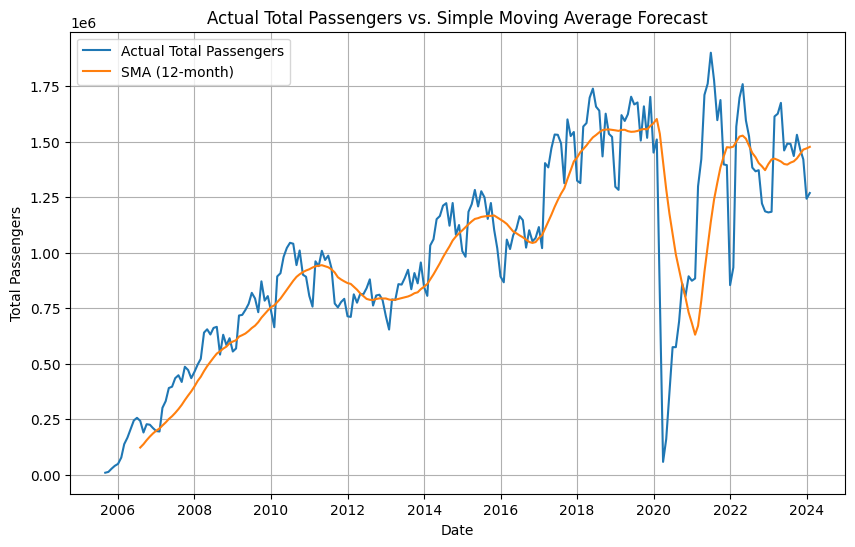

In [21]:
# Simple Moving Average Model
# Assuming 'data' is a DataFrame containing the time series data with a 'TOTAL' column

def simple_moving_average(series, window_size):
    return series.rolling(window=window_size).mean()

# Apply Simple Moving Average to the 'TOTAL' column
sma_window_size = 12  # Adjust the window size as needed
data['TOTAL_SMA'] = simple_moving_average(data['TOTAL'], window_size=sma_window_size)

# Calculate accuracy (using Mean Absolute Error)
actual_values = data['TOTAL']
sma_forecast = data['TOTAL_SMA']

mae = mean_absolute_error(actual_values[sma_window_size:], sma_forecast[sma_window_size:])
accuracy = 1 - (mae / actual_values[sma_window_size:].mean())

print("Accuracy:", accuracy)
print("Mean Absolute Error (MAE):", mae)

# Define threshold (e.g., median of actual values)
threshold = actual_values.median()

# Convert actual and forecast values to binary classes based on threshold
actual_binary = (actual_values > threshold).astype(int)
forecast_binary = (sma_forecast > threshold).astype(int)

# Calculate confusion matrix components
TP = ((actual_binary == 1) & (forecast_binary == 1)).sum()
TN = ((actual_binary == 0) & (forecast_binary == 0)).sum()
FP = ((actual_binary == 0) & (forecast_binary == 1)).sum()
FN = ((actual_binary == 1) & (forecast_binary == 0)).sum()

# Calculate precision, recall, and specificity
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)

# Plot the original 'TOTAL' and the SMA forecast
plt.figure(figsize=(10, 6))
plt.plot(data.index, actual_values, label='Actual Total Passengers')
plt.plot(data.index, sma_forecast, label=f'SMA ({sma_window_size}-month)')
plt.title('Actual Total Passengers vs. Simple Moving Average Forecast')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.legend()
plt.grid(True)
plt.show()


Accuracy: 0.4631059657815715
Mean Absolute Error (MAE): 704189.1772857581
Precision: 0
Recall: 0.0
Specificity: 1.0


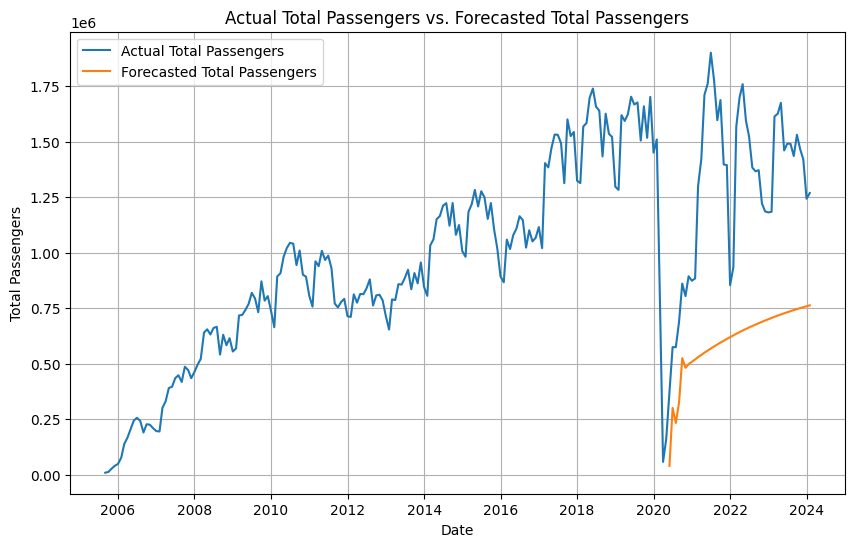

In [25]:
# Autoregressive Integrated Moving Average (ARIMA)
# Function to split data into training and test sets
def train_test_split(data, test_size):
    split_index = int(len(data) * (1 - test_size))
    train_data, test_data = data[:split_index], data[split_index:]
    return train_data, test_data

# Function to fit ARIMA model and forecast
def fit_arima(data, order, test_size):
    train_data, test_data = train_test_split(data, test_size)
    model = ARIMA(train_data, order=order)
    fitted_model = model.fit()
    forecast = fitted_model.forecast(steps=len(test_data))
    mae = mean_absolute_error(test_data, forecast)
    accuracy = 1 - (mae / test_data.mean())
    return accuracy, mae, forecast, test_data

# Parameters
order = (2, 0, 6)  # Replace p, d, and q with the appropriate values
test_size = 0.2  # Adjust the test size as needed

# Fit ARIMA model
accuracy, mae, forecast, test_data = fit_arima(data['TOTAL'], order, test_size)
print("Accuracy:", accuracy)
print("Mean Absolute Error (MAE):", mae)

# Define threshold (e.g., mean or a quantile of actual values)
threshold = test_data.mean()

# Convert actual and forecast values to binary classes based on threshold
actual_binary = (test_data > threshold).astype(int)
forecast_binary = (forecast > threshold).astype(int)

# Calculate confusion matrix components
TP = ((actual_binary == 1) & (forecast_binary == 1)).sum()
TN = ((actual_binary == 0) & (forecast_binary == 0)).sum()
FP = ((actual_binary == 0) & (forecast_binary == 1)).sum()
FN = ((actual_binary == 1) & (forecast_binary == 0)).sum()

# Ensure there are no divisions by zero
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)

# Plot the actual total passengers and the forecasted values
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['TOTAL'], label='Actual Total Passengers')
plt.plot(data.index[-len(forecast):], forecast, label='Forecasted Total Passengers')
plt.title('Actual Total Passengers vs. Forecasted Total Passengers')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.legend()
plt.grid(True)
plt.show()


Accuracy: 0.5856187347775107
Mean Absolute Error (MAE): 543501.6663287042
Precision: 0.5
Recall: 0.5925925925925926
Specificity: 0.1111111111111111


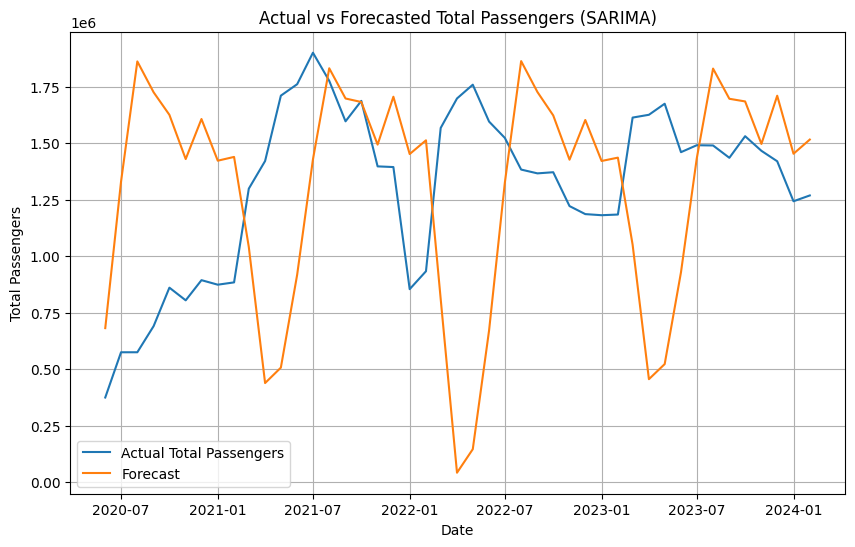

In [26]:
# Seasonal Autoregressive Integrated Moving-Average with Exogenous Regressors (SARIMAX):

# Train-Test Split
train_size = int(len(data) * 0.8)  # 80% for training
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# SARIMA Parameters (Replace these with appropriate values)
order = (0, 0, 6)  # ARIMA parameters (p, d, q)
seasonal_order = (1, 1, 1, 12)  # Seasonal parameters (P, D, Q, m)

# Train SARIMA Model
model = SARIMAX(train_data['TOTAL'], order=order, seasonal_order=seasonal_order, enforce_stationarity=False)
fitted_model = model.fit()

# Forecasting
forecast = fitted_model.forecast(steps=len(test_data))

# Calculate Accuracy (MAE)
mae = mean_absolute_error(test_data['TOTAL'], forecast)
accuracy = 1 - (mae / test_data['TOTAL'].mean())

print("Accuracy:", accuracy)
print("Mean Absolute Error (MAE):", mae)

# Define threshold (e.g., mean of test data)
threshold = test_data['TOTAL'].mean()

# Convert actual and forecast values to binary classes based on threshold
actual_binary = (test_data['TOTAL'] > threshold).astype(int)
forecast_binary = (forecast > threshold).astype(int)

# Calculate confusion matrix components
TP = ((actual_binary == 1) & (forecast_binary == 1)).sum()
TN = ((actual_binary == 0) & (forecast_binary == 0)).sum()
FP = ((actual_binary == 0) & (forecast_binary == 1)).sum()
FN = ((actual_binary == 1) & (forecast_binary == 0)).sum()

# Ensure there are no divisions by zero
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)

# Plot Forecast vs Actual
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['TOTAL'], label='Actual Total Passengers')
plt.plot(test_data.index, forecast, label='Forecast')
plt.title('Actual vs Forecasted Total Passengers (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.legend()
plt.grid(True)
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0mshe4zx/wpc8d8y4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0mshe4zx/umo2seg5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=46543', 'data', 'file=/tmp/tmp0mshe4zx/wpc8d8y4.json', 'init=/tmp/tmp0mshe4zx/umo2seg5.json', 'output', 'file=/tmp/tmp0mshe4zx/prophet_modeli335jn66/prophet_model-20240524124047.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:40:47 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:40:47 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Accuracy: 0.8248944093655521
Mean Absolute Error (MAE): 174192.5538017394
Precision: 0
Recall: 0
Specificity: 0


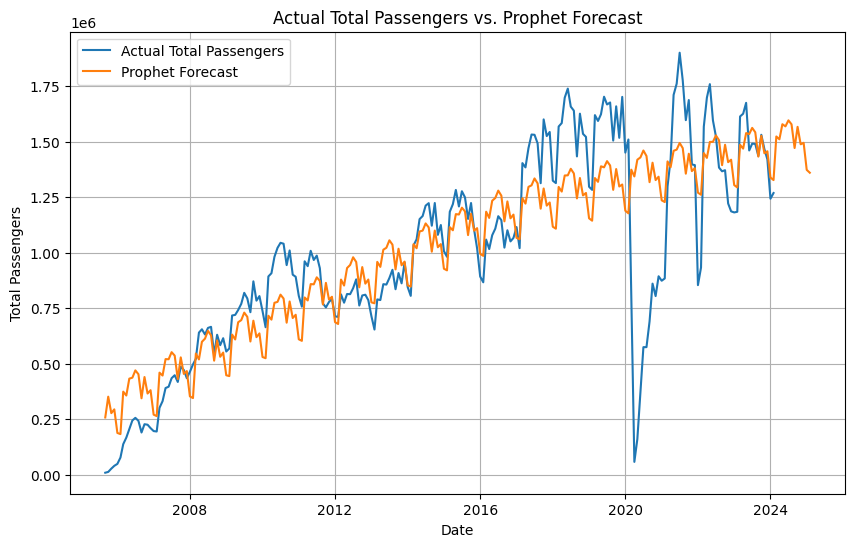

In [31]:
# Prophet


prophet_data = data.reset_index()[['Date', 'TOTAL']]
prophet_data.columns = ['ds', 'y']

# Initialize and fit the Prophet model
model = Prophet()
model.fit(prophet_data)

# Make future predictions
future = model.make_future_dataframe(periods=12, freq='M')  # Adjust periods as needed
forecast = model.predict(future)

# Calculate accuracy
actual_values = data['TOTAL']
forecast_index = forecast.set_index('ds').index
forecast_values = forecast.loc[forecast_index.isin(actual_values.index), 'yhat']
mae = mean_absolute_error(actual_values, forecast_values)
accuracy = 1 - (mae / actual_values.mean())

print("Accuracy:", accuracy)
print("Mean Absolute Error (MAE):", mae)

# Define threshold (e.g., mean of actual values)
threshold = actual_values.mean()

# Convert actual and forecast values to binary classes based on threshold
actual_binary = (actual_values > threshold).astype(int)
forecast_binary = (forecast_values > threshold).astype(int)

# Calculate confusion matrix components
TP = ((actual_binary == 1) & (forecast_binary == 1)).sum()
TN = ((actual_binary == 0) & (forecast_binary == 0)).sum()
FP = ((actual_binary == 0) & (forecast_binary == 1)).sum()
FN = ((actual_binary == 1) & (forecast_binary == 0)).sum()

# Ensure there are no divisions by zero
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['TOTAL'], label='Actual Total Passengers')
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast')
plt.title('Actual Total Passengers vs. Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.legend()
plt.grid(True)
plt.show()


Accuracy: 0.8632745056608462
Mean Absolute Error (MAE): 136012.5792811616
Precision: 0.9238095238095239
Recall: 0.8981481481481481
Specificity: 0.9298245614035088


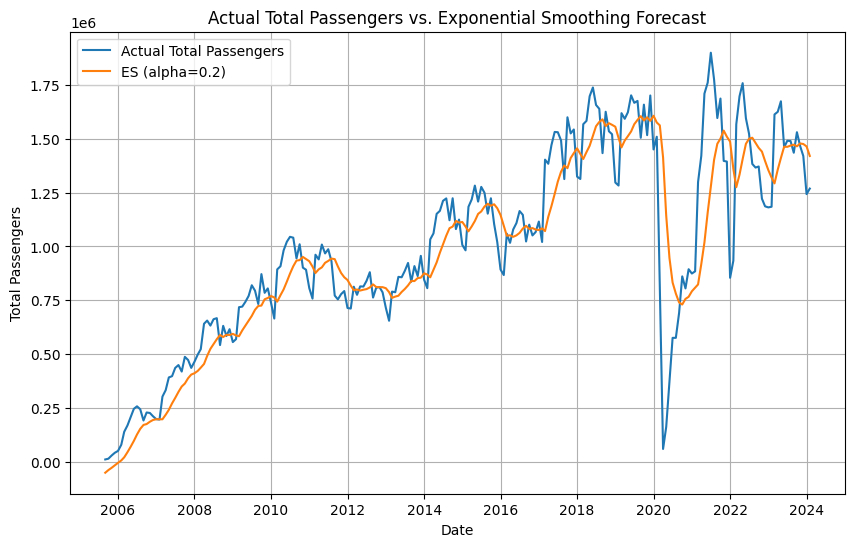

In [32]:
#  Exponential Smoothing

# Apply Exponential Smoothing to the 'TOTAL' column
alpha = 0.2  # Smoothing parameter, adjust as needed
model = ExponentialSmoothing(data['TOTAL'], trend=None, seasonal=None, initialization_method='estimated', freq='MS')
es_forecast = model.fit(smoothing_level=alpha, optimized=False).fittedvalues

# Calculate accuracy (using Mean Absolute Error)
actual_values = data['TOTAL']
mae = mean_absolute_error(actual_values, es_forecast)
accuracy = 1 - (mae / actual_values.mean())

print("Accuracy:", accuracy)
print("Mean Absolute Error (MAE):", mae)

# Define threshold (e.g., mean of actual values)
threshold = actual_values.mean()

# Convert actual and forecast values to binary classes based on threshold
actual_binary = (actual_values > threshold).astype(int)
forecast_binary = (es_forecast > threshold).astype(int)

# Calculate confusion matrix components
TP = ((actual_binary == 1) & (forecast_binary == 1)).sum()
TN = ((actual_binary == 0) & (forecast_binary == 0)).sum()
FP = ((actual_binary == 0) & (forecast_binary == 1)).sum()
FN = ((actual_binary == 1) & (forecast_binary == 0)).sum()

# Ensure there are no divisions by zero
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)

# Plot the original 'TOTAL' and the ES forecast
plt.figure(figsize=(10, 6))
plt.plot(data.index, actual_values, label='Actual Total Passengers')
plt.plot(data.index, es_forecast, label=f'ES (alpha={alpha})')
plt.title('Actual Total Passengers vs. Exponential Smoothing Forecast')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.legend()
plt.grid(True)
plt.show()
